## Exercice 1.2 : Automatisation de la PCA et Comparaison avec T-Sne
Dans cet atelier, nous automatisons le choix du nombre optimal de composantes et utilisons l'erreur de reconstruction pour détecter les flux déviants.

#### 1. Chargement et normalisation rapide

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler

data = pd.read_csv('data/UNSW_NB15_training-set.csv')

features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))

X_scaled = RobustScaler().fit_transform(features)
print("Données prêtes :", X_scaled.shape)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23508\535386136.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features.select_dtypes(include=['object']).columns:


Données prêtes : (82332, 45)


#### 2. Trouver automatiquement le bon nombre de dimensions (Éboulis des valeurs propres)

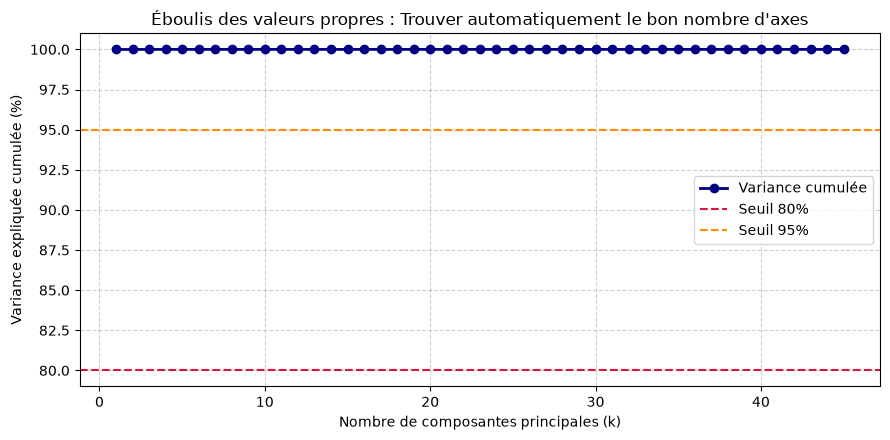

In [2]:
from sklearn.decomposition import PCA
from helper import plot_pca_scree
import numpy as np

# PCA complète sur l'ensemble des 42 axes
pca_full = PCA().fit(X_scaled)
cumul_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Trace la courbe et les seuils optimaux à 80% et 95%
plot_pca_scree(cumul_var, thresholds=[80, 95])

#### 3. Comparaison : t-SNE (non-linéaire) vs PCA (Linéaire)

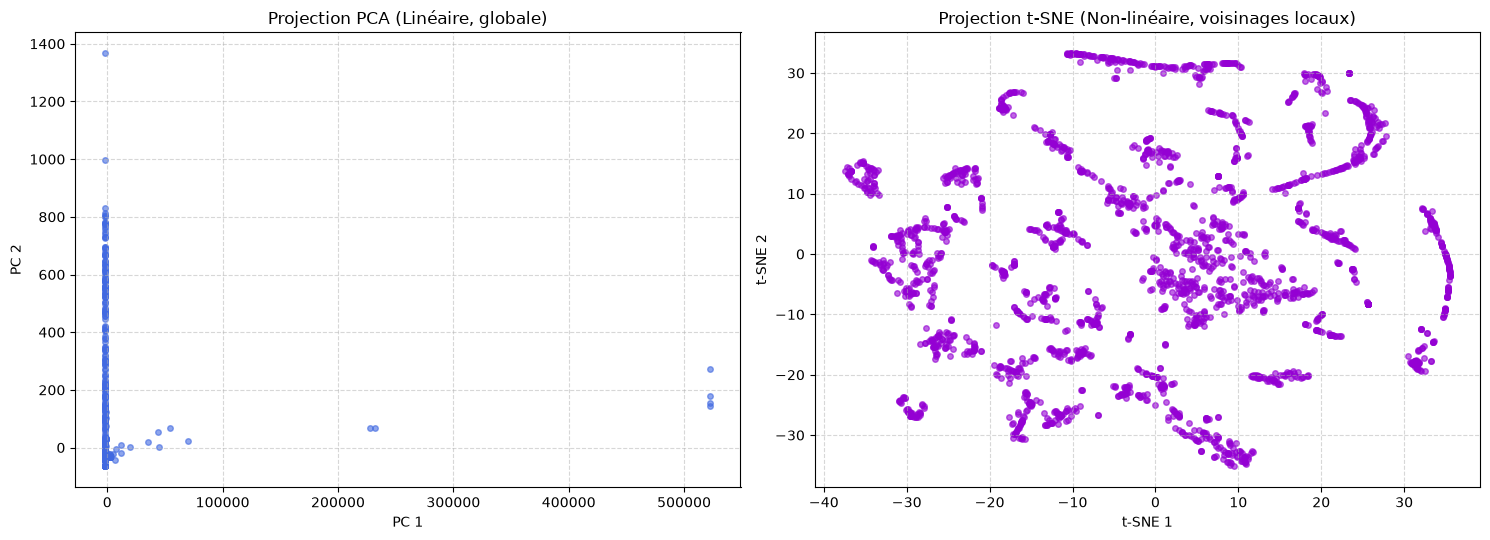

In [3]:
from sklearn.manifold import TSNE
from helper import plot_tsne_comparison

# Échantillon pour un rendu rapide
idx = np.random.RandomState(42).choice(len(X_scaled), size=2500, replace=False)
X_pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42).fit_transform(X_scaled[idx])

plot_tsne_comparison(X_pca_2d[idx], X_tsne)

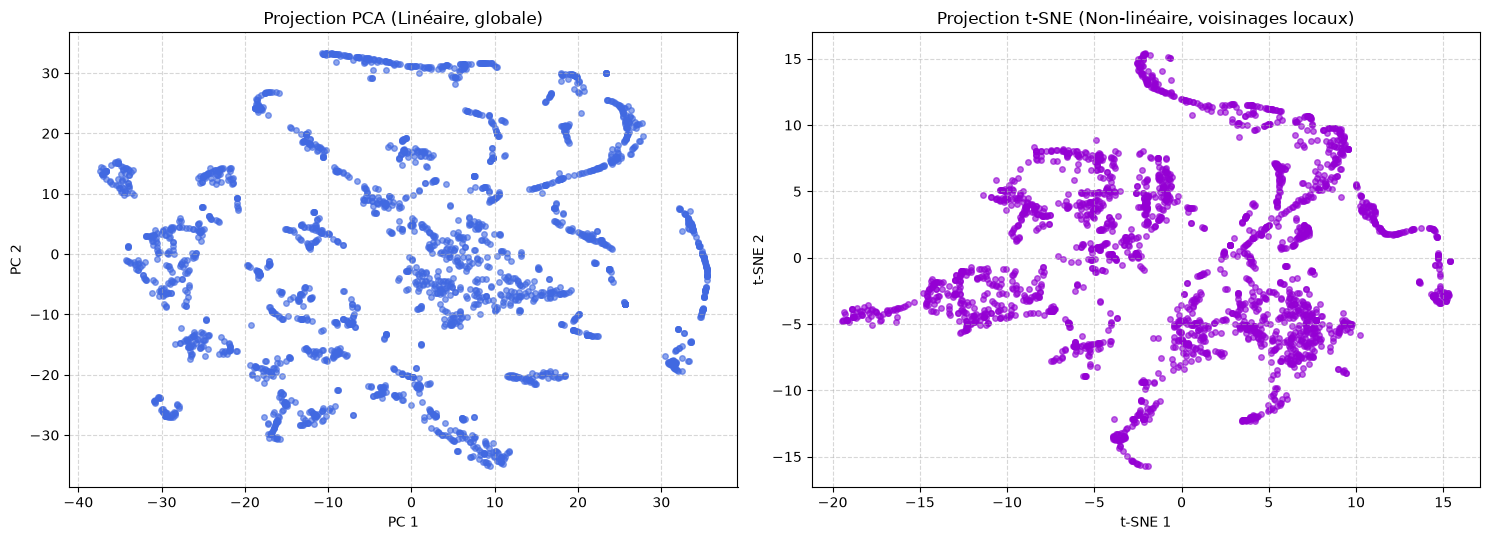

In [4]:
X_tsne1 = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42).fit_transform(X_scaled[idx])
X_tsne2 = TSNE(n_components=3, perplexity=50, max_iter=500, random_state=42).fit_transform(X_scaled[idx])
plot_tsne_comparison(X_tsne1, X_tsne2)

In [5]:
print("Forme de l'embedding t-SNE :", X_tsne.shape)

for i in range(X_tsne.shape[1]):
    print(
        f"Dimension t-SNE {i + 1} : "
        f"min={X_tsne[:, i].min():.2f}, "
        f"max={X_tsne[:, i].max():.2f}, "
        f"moyenne={X_tsne[:, i].mean():.2f}, "
        f"variance={X_tsne[:, i].var():.2f}"
    )

# Corrélation indicative entre les variables originales et les axes t-SNE
X_sample = X_scaled[idx]
correlations = []
    
for j in range(X_sample.shape[1]):
    correlations.append([
        np.corrcoef(X_sample[:, j], X_tsne[:, i])[0, 1]
        for i in range(X_tsne.shape[1])
    ])

feature_names = features.columns
corr_tsne = pd.DataFrame(
    correlations,
    index=feature_names,
    columns=["t-SNE 1", "t-SNE 2"]
)

print("\nVariables les plus associées à chaque dimension t-SNE :")

for dimension in corr_tsne.columns:
    print(f"\n{dimension}")
    print(
        corr_tsne[dimension]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .to_string()
    )

Forme de l'embedding t-SNE : (2500, 2)
Dimension t-SNE 1 : min=-37.45, max=35.50, moyenne=-0.22, variance=355.49
Dimension t-SNE 2 : min=-35.16, max=33.31, moyenne=-0.01, variance=303.64

Variables les plus associées à chaque dimension t-SNE :

t-SNE 1
state               0.642104
sttl                0.610984
ct_srv_dst          0.608887
ct_srv_src          0.607846
ct_dst_src_ltm      0.590351
ct_src_dport_ltm    0.571638
ct_dst_sport_ltm    0.556442
ct_dst_ltm          0.530328
ct_src_ltm          0.521258
dwin                0.496326

t-SNE 2
ct_state_ttl    0.614568
sttl            0.501375
state           0.495819
dload           0.461741
dwin            0.405764
dmean           0.363252
swin            0.343463
dtcpb           0.331099
label           0.321831
stcpb           0.314770


In [6]:
# Classification à partir des deux dimensions t-SNE
# Les étiquettes doivent correspondre aux lignes échantillonnées par idx.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=["t-SNE 1", "t-SNE 2"]
)
y_tsne = data.iloc[idx]["attack_cat"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_tsne_df,
    y_tsne,
    test_size=0.2,
    random_state=42,
    stratify=y_tsne
)

scalers = {
    "Sans normalisation": None,
    "RobustScaler": RobustScaler(),
    "StandardScaler": StandardScaler()
}

results_tsne = []

for scaling_name, scaler_model in tqdm(scalers.items()):
    if scaler_model is None:
        X_train_final = X_train.to_numpy()
        X_test_final = X_test.to_numpy()
    else:
        X_train_final = scaler_model.fit_transform(X_train)
        X_test_final = scaler_model.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
    model.fit(X_train_final, y_train)
    predictions = model.predict(X_test_final)

    results_tsne.append({
        "Méthode": scaling_name,
        "Dimensions": X_train_final.shape[1],
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
        "F1-score": f1_score(y_test, predictions, average="weighted")
    })

results_tsne_df = pd.DataFrame(results_tsne)
results_tsne_df.sort_values("F1-score", ascending=False)

  0%|          | 0/3 [00:00<?, ?it/s]c:\Users\Lucas\8IAR80-Cybersecurity-AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
 33%|███▎      | 1/3 [00:00<00:00,  4.84it/s]c:\Users\Lucas\8IAR80-Cybersecurity-AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
 67%|██████▋   | 2/3 [00:00<00:00,  4.91it/s]c:\Users\Lucas\8IAR80-Cybersecurity-AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
100%|██████████| 3/3 [00:00<00:00,  4.90it/s]


,Méthode,Dimensions,Accuracy,Balanced accuracy,F1-score
0,Sans normalisation,2,0.83,0.569636,0.835518
1,RobustScaler,2,0.83,0.569636,0.835518
2,StandardScaler,2,0.83,0.569636,0.835518
